# OceanScan - Real Time Prediction (webcam)

Live webcam detection with the trained `best.pt` model.

Pipeline per frame:
1. **Noise filtering** - the same `filter_noise` used in `noise_filtering.ipynb` (median -> bilateral -> CLAHE)
2. **Prediction** - YOLOv8n on the cleaned frame
3. **Live view** - shown inline in the notebook: raw input on the LEFT, model view on the RIGHT
4. **Save-on-detect** - frames with boxes above the confidence threshold are saved to `output/prediction/realtime_prediction/image/`
5. **Input archive** - every processed raw frame is saved to `input/realtime/` and its noise-filtered version to `output/noise_filter/input_noise_filter/real_time/`

> The loop is throttled to a few frames per second (default `~1`), auto-stops after `RUN_SECONDS`, or you can set `stop_loop = True`.

## 1. Setup

In [1]:
from pathlib import Path
import json

import cv2
import numpy as np
from ultralytics import YOLO

ROOT = Path(r"D:\1. Project Program\1.SIH\SonarVision")
BEST = ROOT / "backend" / "best.pt"
NF_NB = ROOT / "backend" / "noise_filtering.ipynb"

CLASS_NAMES = {0: "human", 1: "pipe", 2: "shipwreck", 3: "crabpot", 4: "cylinder", 5: "plane"}
CONF_THRESHOLD = 0.50   # only draw / save boxes above this confidence
SAVE_DIR = ROOT / "output" / "predictions" / "realtime_prediction" / "image"
INPUT_DIR = ROOT / "input" / "realtime"
NF_DIR = ROOT / "output" / "noise_filter" / "input_noise_filter" / "real_time"

## 2. Load model + noise filter

Reuses `filter_noise` straight out of `noise_filtering.ipynb` (same loader trick as `image_prediction.ipynb`).

In [2]:
def load_noise_filter_from_nb(nb_path: Path):
    nb = json.loads(nb_path.read_text(encoding="utf-8"))
    ns = {"__name__": "noise_filtering_mod", "cv2": cv2, "np": np, "Path": Path}
    for cell in nb["cells"]:
        if cell.get("cell_type") != "code":
            continue
        source = "".join(cell.get("source", []))
        if "def filter_noise" in source or "def preprocess_for_model" in source:
            exec(source, ns)
    return ns


fns = load_noise_filter_from_nb(NF_NB)
filter_noise = fns["filter_noise"]

model = YOLO(str(BEST))
print("Model loaded:", BEST)
print("Noise filter loaded from:", NF_NB)

Model loaded: D:\1. Project Program\1.SIH\OceanScan\backend\best.pt
Noise filter loaded from: D:\1. Project Program\1.SIH\OceanScan\backend\noise_filtering.ipynb


## 3. Run real-time webcam detection

Each processed frame: noise-filter -> predict -> draw boxes. The live view is drawn **inline** (raw left / model right) and only a few frames per second are processed (`FPS_LIMIT`) to keep it light.

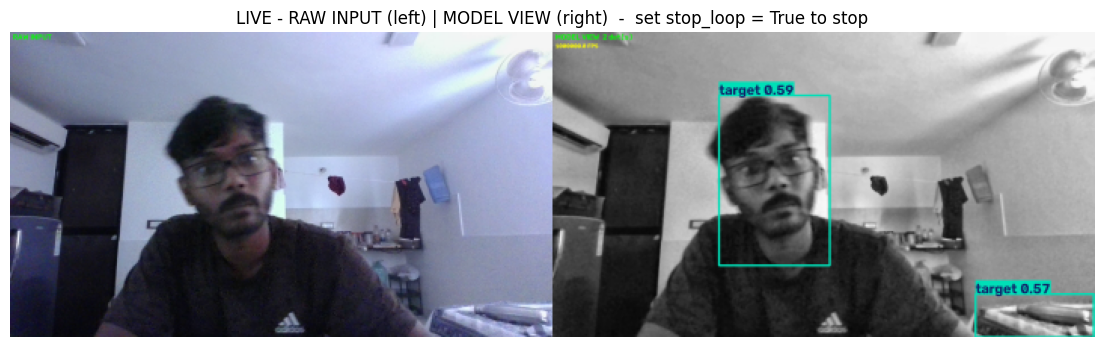


Stopped. 36 detection frame(s) saved to D:\1. Project Program\1.SIH\OceanScan\output\predictions\realtime_prediction\image


KeyboardInterrupt: 

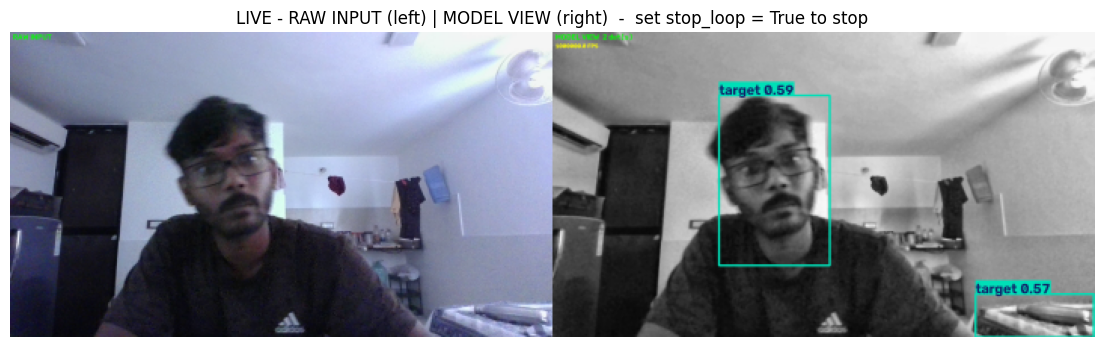

In [3]:
%matplotlib inline
import time
import matplotlib.pyplot as plt
from IPython.display import display, clear_output

FPS_LIMIT = 5.0        # process at most ~5 frames per second (increase for smoother)
RUN_SECONDS = 60       # auto-stop after this long
for d in (SAVE_DIR, INPUT_DIR, NF_DIR):
    d.mkdir(parents=True, exist_ok=True)

cap = cv2.VideoCapture(0, cv2.CAP_DSHOW)  # DirectShow -> faster open on Windows
if not cap.isOpened():
    print("ERROR: cannot open webcam (index 0). Is it in use?")
    raise SystemExit

ok, raw = cap.read()
if not ok:
    print("ERROR: webcam opened but no frame received - exiting.")
    cap.release()
    raise SystemExit

vis0 = np.hstack([raw, np.zeros_like(raw)])
fig, ax = plt.subplots(figsize=(14, 5.5), facecolor="white")
im_handle = ax.imshow(cv2.cvtColor(vis0, cv2.COLOR_BGR2RGB))
ax.axis("off")
ax.set_title("LIVE - RAW INPUT (left) | MODEL VIEW (right)  -  set stop_loop = True to stop")

interval = 1.0 / FPS_LIMIT
last_t = 0.0
count = 0
frame_no = 0
start = time.time()
last_printed = start

stop_loop = False
print(f"Webcam open. Processing ~{FPS_LIMIT:.0f} frame(s)/s.")
print(f"Runs for {RUN_SECONDS} s, or set stop_loop = True to stop early.")
print(f"Detection frames will be saved to: {SAVE_DIR}\n")

try:
    while not stop_loop and time.time() - start < RUN_SECONDS:
        ok, raw = cap.read()
        if not ok:
            print("No frame received - exiting.")
            break

        now = time.time()
        if now - last_t < interval:
            continue  # too soon - skip this camera frame (fewer frames processed)
        last_t = now

        # 1) Apply the SAME noise filter as the prediction pipeline
        #    (median -> bilateral -> CLAHE). Filter only; YOLO letterboxes internally.
        clean = filter_noise(raw)

        # 1b) Archive every processed input frame: raw -> input/realtime, cleaned -> noise_filter
        frame_no += 1
        cv2.imwrite(str(INPUT_DIR / f"realtime_input_{frame_no:04d}.png"), raw)
        cv2.imwrite(str(NF_DIR / f"realtime_nf_{frame_no:04d}.png"), clean)

        # 2) Detection
        result = model(clean, conf=CONF_THRESHOLD, verbose=False)[0]
        boxes = result.boxes
        det = boxes is not None and len(boxes) > 0

        # 3) Annotate (boxes + labels) only when something is found
        annotated = result.plot() if det else clean.copy()

        # 4) Save ONLY frames that have detections above the confidence threshold
        if det:
            count += 1
            out_p = SAVE_DIR / f"realtime_pred_{count:04d}.png"
            cv2.imwrite(str(out_p), annotated)
            dets = [
                f"{CLASS_NAMES.get(int(b.cls[0]), int(b.cls[0]))} {float(b.conf[0]):.2f}"
                for b in boxes
            ]
            print(f"  saved {out_p.name}  ->  {dets}")

        # 5) Build one side-by-side image and refresh the single inline figure
        fps_here = 1.0 / max(now - last_t, 1e-6)

        raw_l = raw.copy()
        cv2.putText(raw_l, "RAW INPUT", (10, 30),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 255, 0), 2)
        ann_l = annotated.copy()
        cv2.putText(ann_l,
                    "MODEL VIEW" + (f"  {len(boxes)} det(s)" if det else "  no detections"),
                    (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 255, 0), 2)
        cv2.putText(ann_l, f"{fps_here:.1f} FPS", (10, 60),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 255), 2)

        vis = np.hstack([raw_l, ann_l])
        # shrink display to speed up inline rendering (saved images stay full size)
        scale = 720.0 / float(vis.shape[1])
        vis_small = cv2.resize(
            vis, (720, max(1, int(vis.shape[0] * scale))),
            interpolation=cv2.INTER_AREA,
        )
        im_handle.set_data(cv2.cvtColor(vis_small, cv2.COLOR_BGR2RGB))
        if now - last_printed >= 2.0:
            print(f"  live {fps_here:.1f} FPS | saved so far: {count}")
            last_printed = now
        clear_output(wait=True)
        display(fig)
finally:
    cap.release()
    print(f"\nStopped. {count} detection frame(s) saved to {SAVE_DIR}")
    print(f"Saved {frame_no} raw input frame(s) to {INPUT_DIR}")
    print(f"Saved {frame_no} noise-filtered frame(s) to {NF_DIR}")